# TP SEABORN – DONNEE SPORTIVE

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pyparsing import col


sns.set_theme(style='whitegrid')
df = pd.read_csv(r'C:\Users\mcasteras\Desktop\Projets\M2\Visualisation des donnée matplotlib et seaborn\Data\all_players_clean.csv')


## 1. Compréhension du dataset


Quelles sont les colonnes quantitatives ? Les colonnes qualitatives ?


In [5]:

print('Colonnes quantitatives :', df.select_dtypes(include='number').columns.tolist())
print('Colonnes qualitatives :', df.select_dtypes(exclude='number').columns.tolist())

Colonnes quantitatives : ['OVR', 'PAC', 'SHO', 'PAS', 'DRI', 'DEF', 'PHY', 'Acceleration', 'Sprint.Speed', 'Positioning', 'Finishing', 'Shot.Power', 'Long.Shots', 'Volleys', 'Penalties', 'Vision', 'Crossing', 'Free.Kick.Accuracy', 'Short.Passing', 'Long.Passing', 'Curve', 'Dribbling', 'Agility', 'Balance', 'Reactions', 'Ball.Control', 'Composure', 'Interceptions', 'Heading.Accuracy', 'Def.Awareness', 'Standing.Tackle', 'Sliding.Tackle', 'Jumping', 'Stamina', 'Strength', 'Aggression', 'Weak.foot', 'Skill.moves', 'Height', 'Weight', 'Age', 'GK.Diving', 'GK.Handling', 'GK.Kicking', 'GK.Positioning', 'GK.Reflexes']
Colonnes qualitatives : ['Name', 'Position', 'Preferred.foot', 'Alternative.positions', 'Nation', 'League', 'Team', 'url', 'gender']


Quel est le joueur ayant la meilleure note OVR ?


In [6]:
player_max = df.loc[df['OVR'].idxmax()]
print('Joueur :', player_max['Name'])
print('OVR :', player_max['OVR'])

Joueur : Kylian Mbappé
OVR : 91


Quelles sont les 5 ligues les plus représentées ?


In [7]:
print(df['League'].value_counts().head(5))

League
Sudamericana        826
MLS                 762
EFL Championship    683
EFL League One      615
Premier League      597
Name: count, dtype: int64


## 2. Visualisations UNIVARIÉES

### A. Variables quantitatives

Objectif : manipuler histplot , kdeplot .

Afficher la distribution de la note générale OVR.

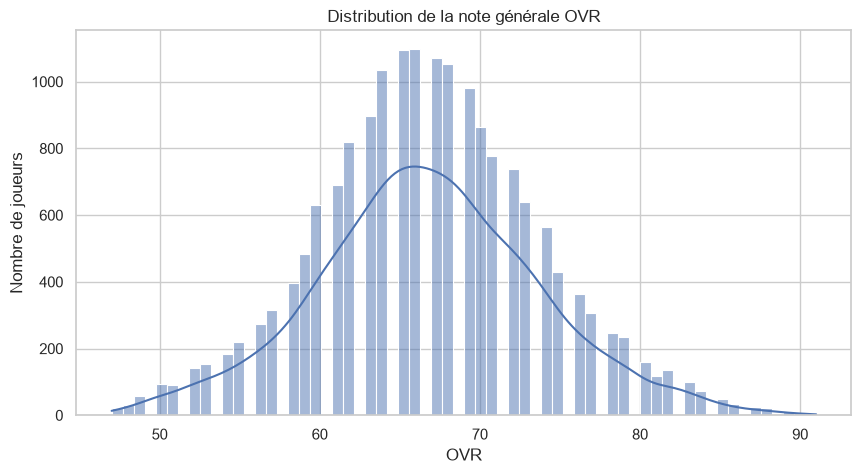

In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='OVR', kde= True)
plt.title('Distribution de la note générale OVR')
plt.xlabel('OVR')
plt.ylabel('Nombre de joueurs')
plt.show()

Les notes OVR sont surtout concentrées autour de 67, avec peu de joueurs aux valeurs extrêmes.

Comparer la distribution du PAC (vitesse) et du PHY (physique) dans deux histogrammes côte à côte.

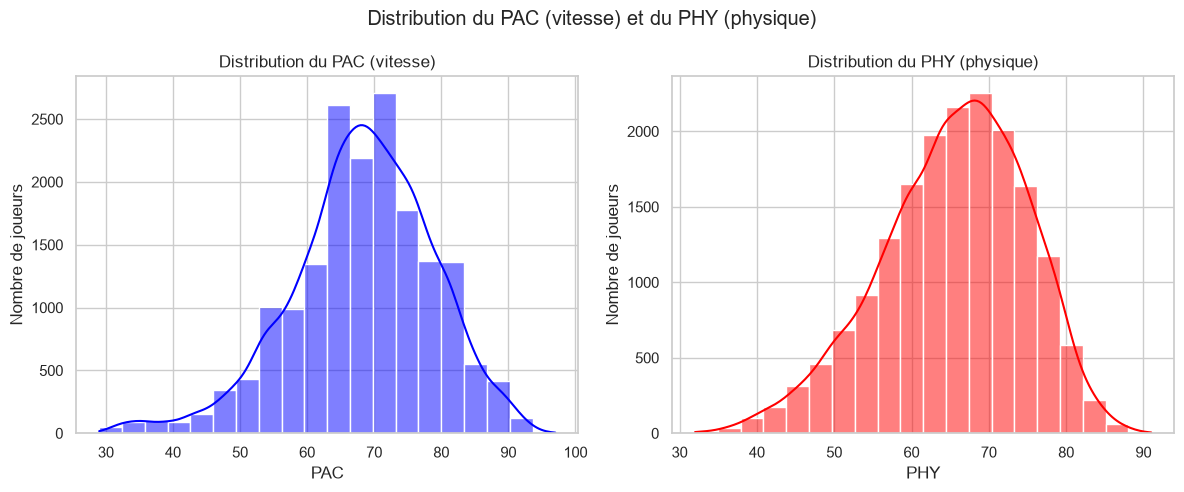

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=df, x='PAC', bins=20, kde=True, ax=axes[0], color="blue")
axes[0].set_title('Distribution du PAC (vitesse)')
axes[0].set_xlabel('PAC')
axes[0].set_ylabel('Nombre de joueurs')

sns.histplot(data=df, x='PHY', bins=20, kde=True, ax=axes[1],color = "red")
axes[1].set_title('Distribution du PHY (physique)')
axes[1].set_xlabel('PHY')
axes[1].set_ylabel('Nombre de joueurs')

plt.suptitle('Distribution du PAC (vitesse) et du PHY (physique)')
plt.tight_layout()
plt.show()

Dessiner une densité (kdeplot) pour la statistique DRI (dribble).

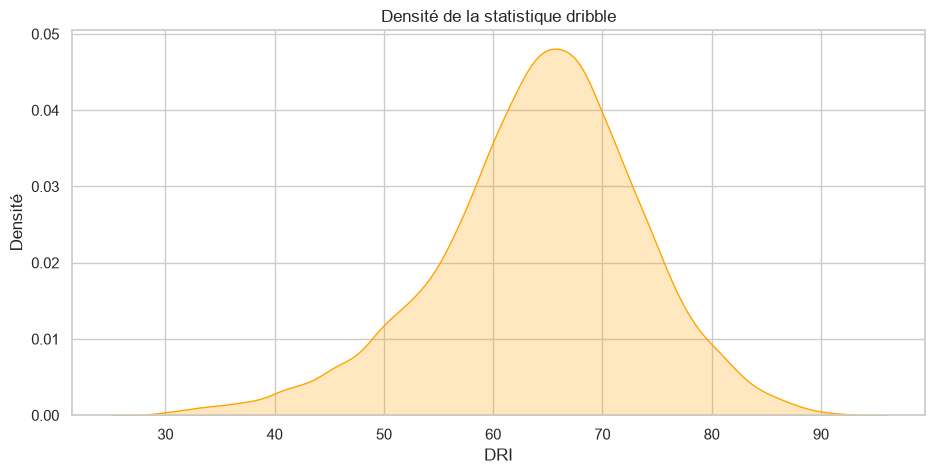

In [10]:
plt.figure(figsize=(11, 5))
sns.kdeplot(data=df, x='DRI', fill=True, color='orange')
plt.title('Densité de la statistique dribble')
plt.xlabel('DRI')
plt.ylabel('Densité')
plt.show()

### B. Variables qualitatives

Objectif : manipuler countplot.

Quels sont les championnats les plus représentés ? (League)

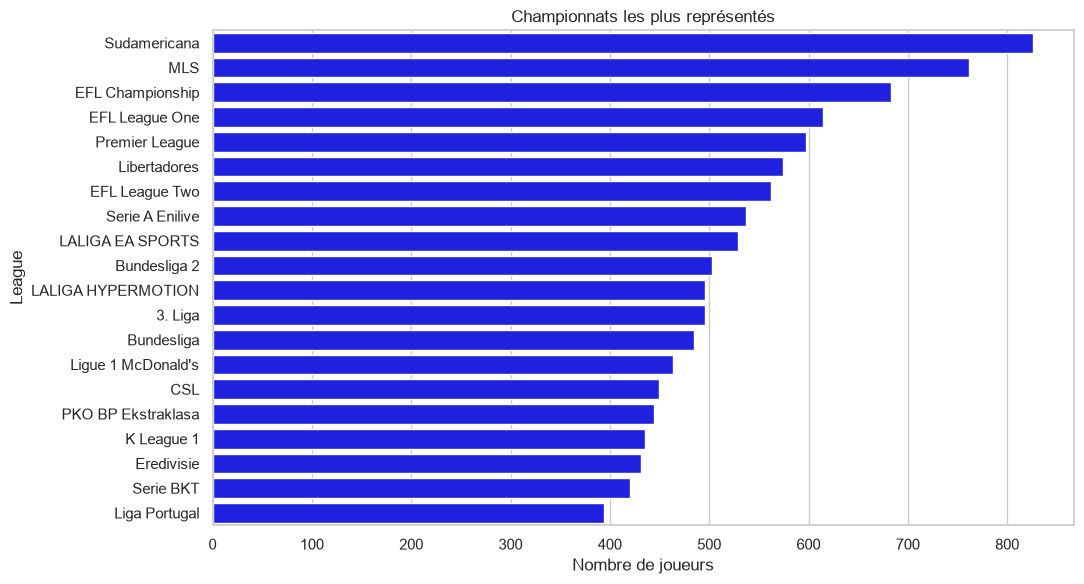

In [11]:
top_ligues = df['League'].value_counts().head(20).index

plt.figure(figsize=(11, 6))
sns.countplot(data=df[df['League'].isin(top_ligues)], y='League', order=top_ligues, color='blue')
plt.title('Championnats les plus représentés')
plt.xlabel('Nombre de joueurs')
plt.ylabel('League')
plt.tight_layout()
plt.show()

Quel pays est le plus présent dans le dataset ?

Pays le plus présent : England


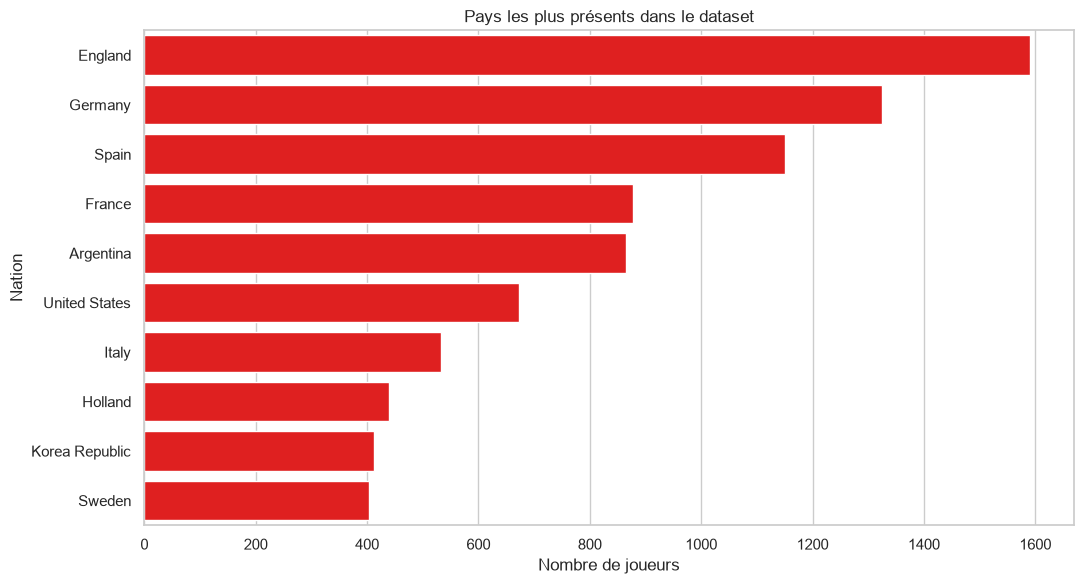

In [12]:
top_nations = df['Nation'].value_counts().head(10).index
print('Pays le plus présent :', df['Nation'].value_counts().idxmax())

plt.figure(figsize=(11, 6))
sns.countplot(data=df[df['Nation'].isin(top_nations)], y='Nation', order=top_nations, color='red')
plt.title('Pays les plus présents dans le dataset')
plt.xlabel('Nombre de joueurs')
plt.ylabel('Nation')
plt.tight_layout()
plt.show()

## 3. Visualisations BIVARIÉES

Objectif : scatterplot, regplot, jointplot, pairplot.

Y a-t-il une relation entre PAC (vitesse) et OVR ?

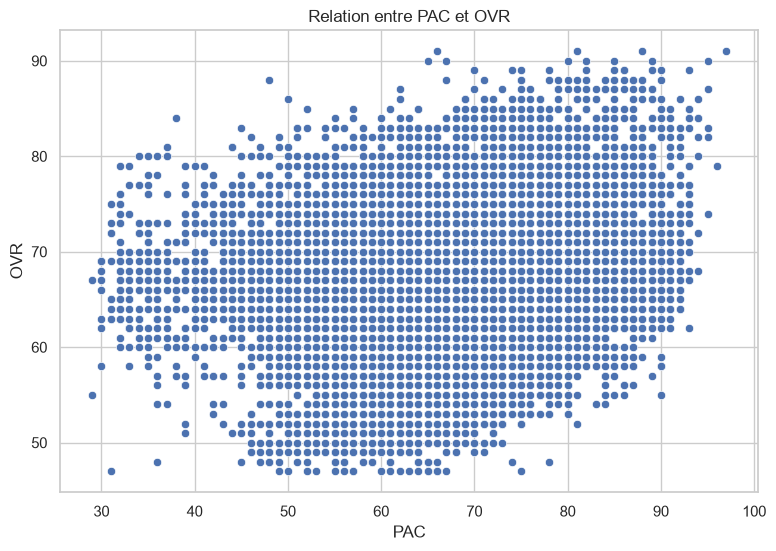

Corrélation entre PAC et OVR : 0.29


In [13]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='PAC', y='OVR')
plt.title('Relation entre PAC et OVR')
plt.xlabel('PAC')
plt.ylabel('OVR')
plt.show()

correlation_pac_ovr = df[['PAC', 'OVR']].corr().iloc[0, 1]
print(f'Corrélation entre PAC et OVR : {correlation_pac_ovr:.2f}')

On observe une relation faible entre PAC et OVR.

Faire une régression linéaire entre DRI et OVR.

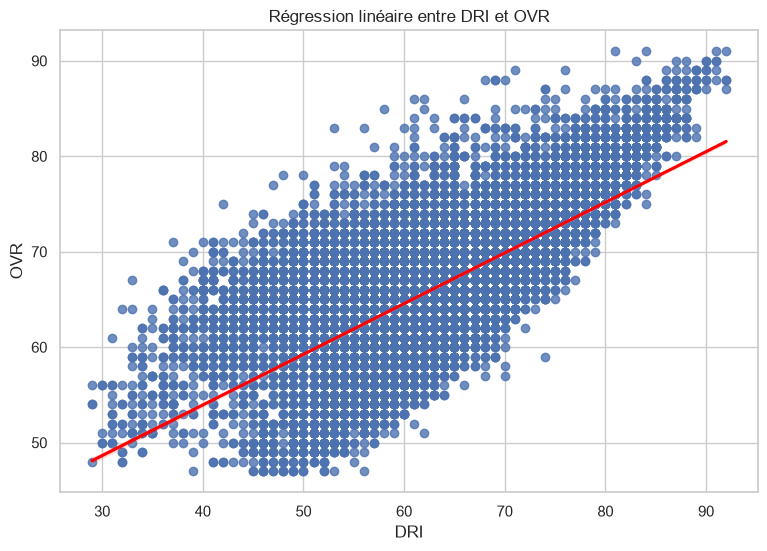

In [14]:
plt.figure(figsize=(9, 6))
sns.regplot(data=df, x='DRI', y='OVR', line_kws={'color': 'red'})
plt.title('Régression linéaire entre DRI et OVR')
plt.xlabel('DRI')
plt.ylabel('OVR')
plt.show()

La relation est nettement positive : les joueurs avec un DRI élevé ont généralement un meilleur OVR.

Utiliser un jointplot pour visualiser PAS vs DRI.

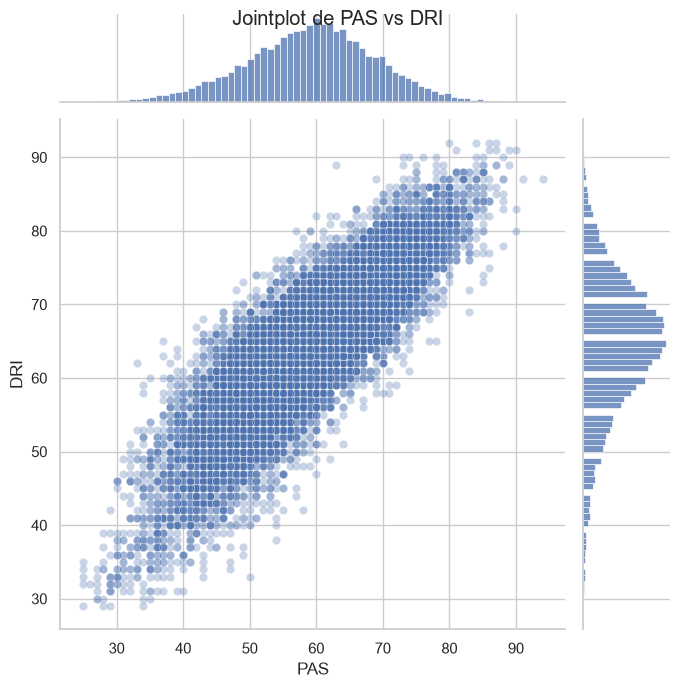

In [15]:

graphique = sns.jointplot(data=df, x='PAS', y='DRI', kind='scatter', alpha=0.3, height=7)
graphique.fig.suptitle('Jointplot de PAS vs DRI')
plt.show()

Faire un pairplot complet sur les colonnes : OVR, PAC, SHO, PAS, DRI.

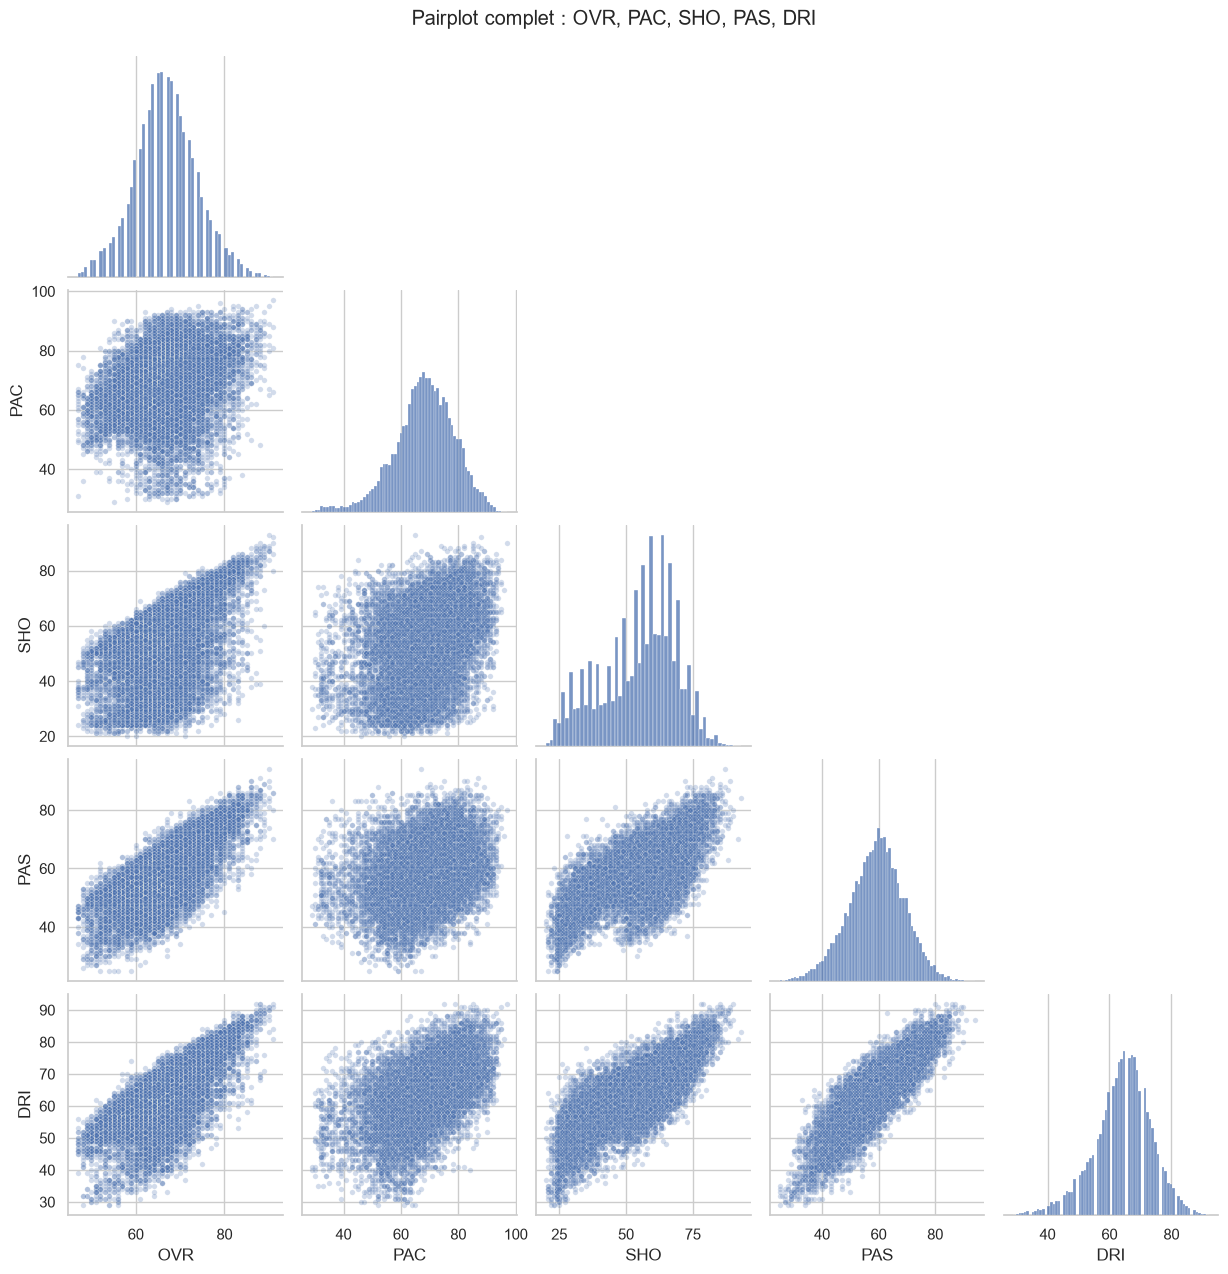

In [16]:
donnees_pairplot = df[['OVR', 'PAC', 'SHO', 'PAS', 'DRI']].dropna()

graphique_pairplot = sns.pairplot(donnees_pairplot, corner=True, plot_kws={'alpha': 0.25, 's': 15})
graphique_pairplot.fig.suptitle('Pairplot complet : OVR, PAC, SHO, PAS, DRI', y=1.02)
plt.show()

### Comparaisons par catégorie

Objectif : boxplot, violinplot, barplot.

Comparer les notes OVR par League → boxplot.

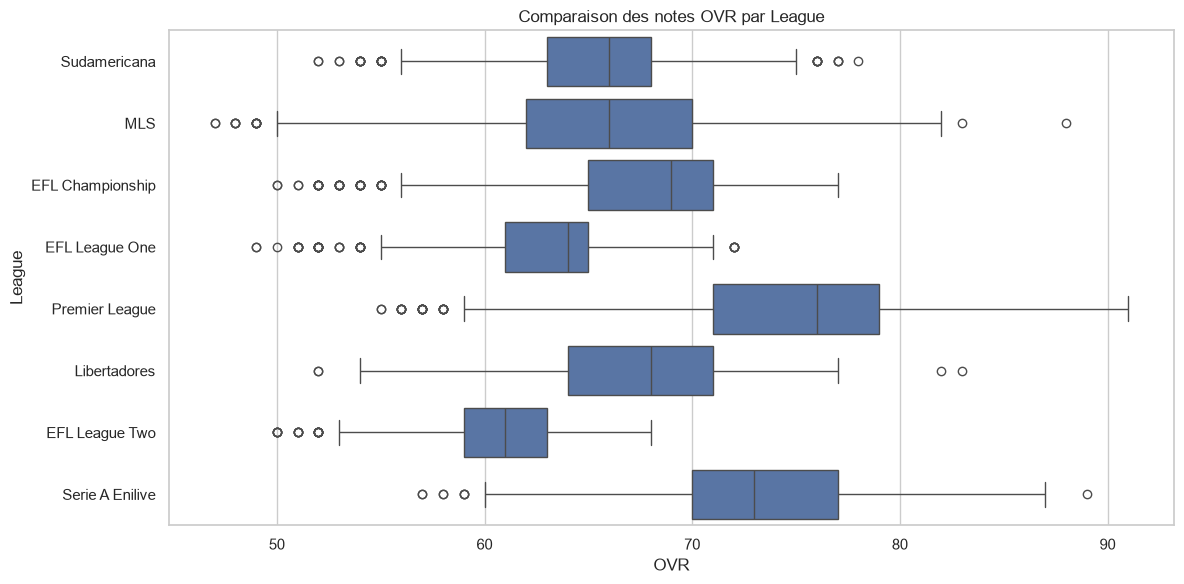

In [17]:
top_8_ligues = df['League'].value_counts().head(8).index
df_top_8_ligues = df[df['League'].isin(top_8_ligues)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top_8_ligues, x='OVR', y='League', order=top_8_ligues)
plt.title('Comparaison des notes OVR par League')
plt.xlabel('OVR')
plt.ylabel('League')
plt.tight_layout()
plt.show()

In [18]:
# Six grands championnats européens
meilleures_ligues = [
    'Premier League',
    'LALIGA EA SPORTS',
    'Serie A Enilive',
    'Bundesliga',
    "Ligue 1 McDonald's",
    'Liga Portugal'
]
trois_meilleures_ligues = meilleures_ligues[:3]

classement_championnats = (
    df[df['League'].isin(meilleures_ligues)]
    .groupby('League', as_index=False)
    .agg(OVR_moyen=('OVR', 'mean'), Nombre_de_joueurs=('OVR', 'size'))
    .set_index('League')
    .reindex(meilleures_ligues)
    .reset_index()
)

print('Six grands championnats retenus :')
print(classement_championnats.round(2).to_string(index=False))

Six grands championnats retenus :
            League  OVR_moyen  Nombre_de_joueurs
    Premier League      74.27                597
  LALIGA EA SPORTS      73.87                529
   Serie A Enilive      73.27                537
        Bundesliga      72.76                485
Ligue 1 McDonald's      71.94                464
     Liga Portugal      69.72                394


Comparer les statistiques PAC, DRI, SHO entre 3 grands championnats.

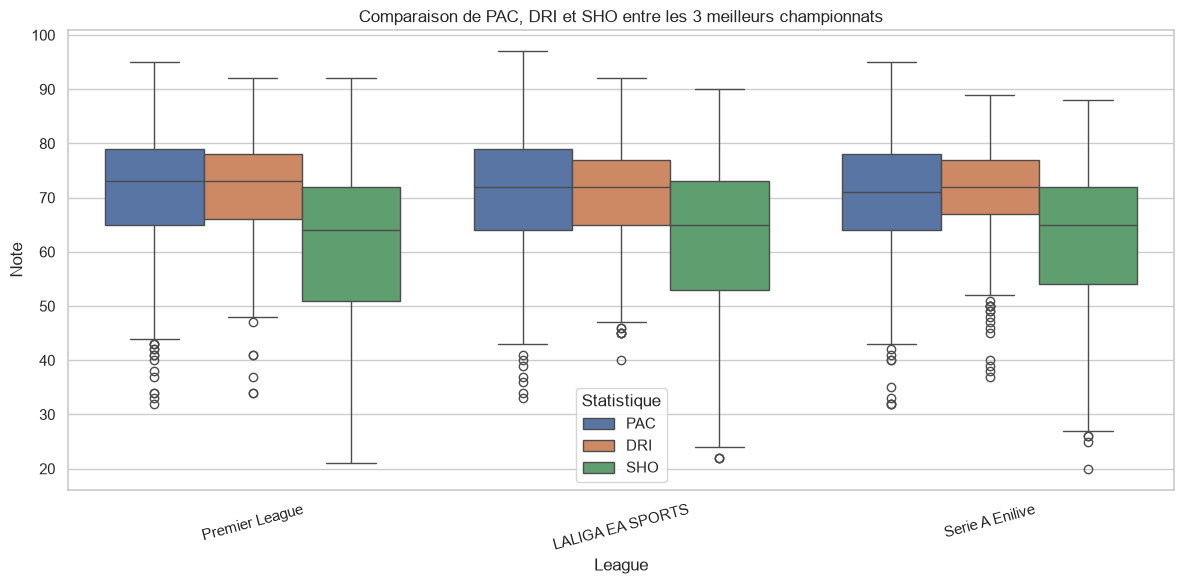

In [19]:
donnees_trois_ligues = df[df['League'].isin(trois_meilleures_ligues)].melt(
    id_vars='League', value_vars=['PAC', 'DRI', 'SHO'],
    var_name='Statistique', value_name='Note'
)

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=donnees_trois_ligues,
    x='League',
    y='Note',
    hue='Statistique',
    order=trois_meilleures_ligues
)
plt.title('Comparaison de PAC, DRI et SHO entre les 3 meilleurs championnats')
plt.xlabel('League')
plt.ylabel('Note')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Créer un violinplot de DRI par poste si tu as la colonne (ou par ligue).

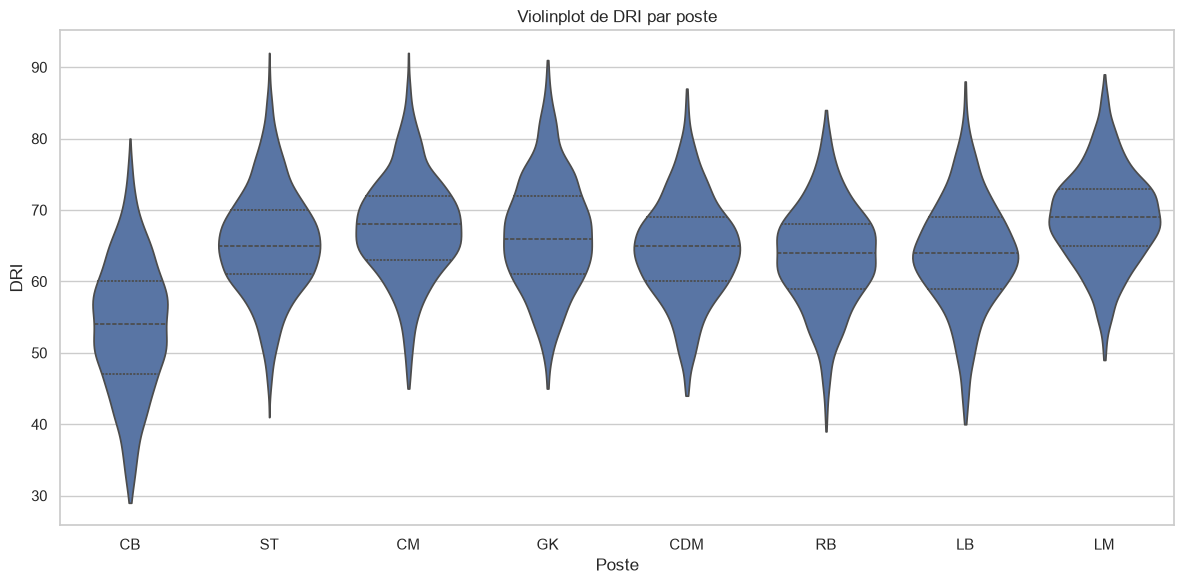

In [20]:
top_postes = df['Position'].value_counts().head(8).index
df_top_postes = df[df['Position'].isin(top_postes)]

plt.figure(figsize=(12, 6))
sns.violinplot(data=df_top_postes, x='Position', y='DRI', order=top_postes, inner='quartile', cut=0)
plt.title('Violinplot de DRI par poste')
plt.xlabel('Poste')
plt.ylabel('DRI')
plt.tight_layout()
plt.show()

Quel championnat a la plus grande moyenne physique (PHY) ? → barplot.

Championnat avec la plus grande moyenne PHY :             League        PHY
16  Premier League  69.916248


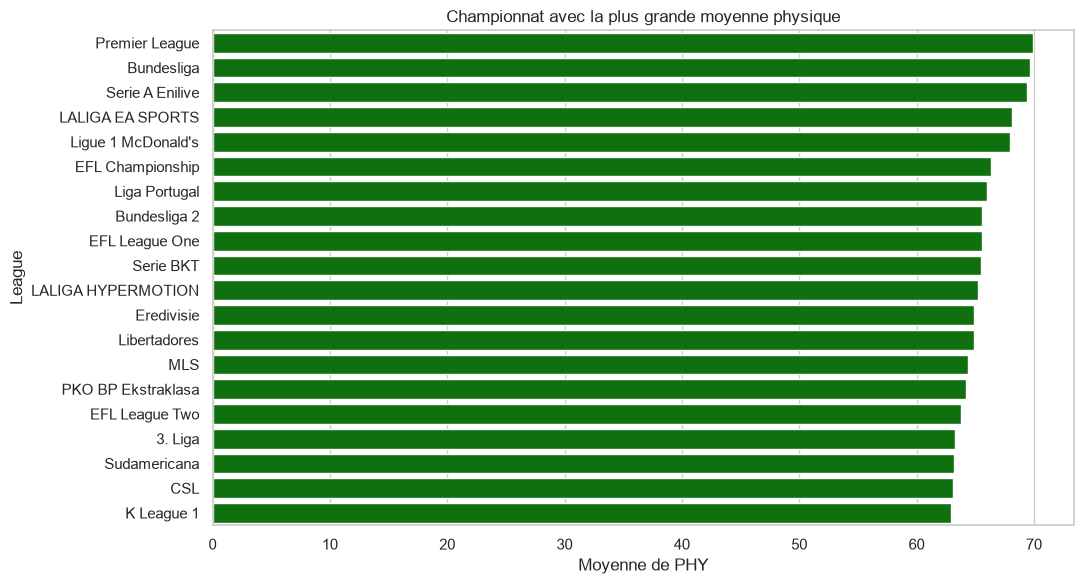

In [21]:
moyenne_phy = (
    df[df['League'].isin(top_ligues)]
    .groupby('League', as_index=False)['PHY'].mean()
    .sort_values('PHY', ascending=False)
)
print('Championnat avec la plus grande moyenne PHY :', moyenne_phy.head(1))

plt.figure(figsize=(11, 6))
sns.barplot(data=moyenne_phy, x='PHY', y='League', color='green')
plt.title('Championnat avec la plus grande moyenne physique')
plt.xlabel('Moyenne de PHY')
plt.ylabel('League')
plt.tight_layout()
plt.show()

## 4. Visualisations MULTIVARIÉES

Objectif : catplot, lmplot, heatmap, FacetGrid.

Faire un catplot pour comparer OVR par League, séparé par Nation (top 5 nations uniquement).

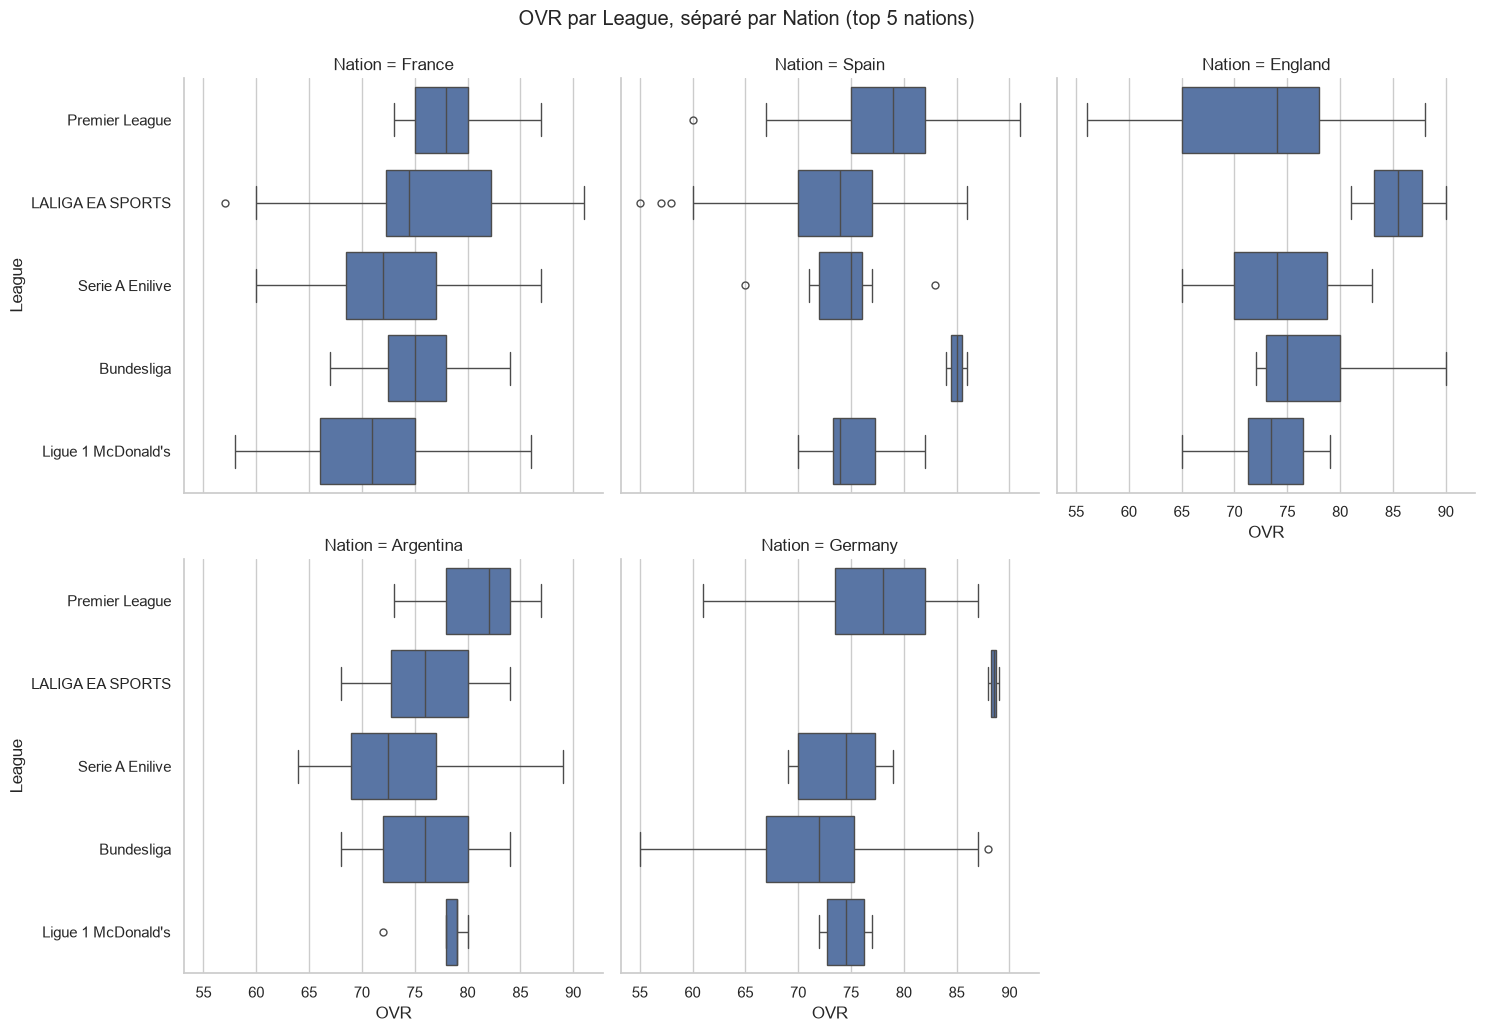

In [22]:
top_5_nations = df['Nation'].value_counts().head(5).index
top_5_ligues = meilleures_ligues[:5]
donnees_catplot = df[df['Nation'].isin(top_5_nations) & df['League'].isin(top_5_ligues)]

graphique_cat = sns.catplot(
    data=donnees_catplot,
    x='OVR',
    y='League',
    col='Nation',
    col_wrap=3,
    kind='box',
    order=top_5_ligues
)
graphique_cat.fig.suptitle('OVR par League, séparé par Nation (top 5 nations)', y=1.03)
graphique_cat.set_axis_labels('OVR', 'League')
plt.show()

Faire un lmplot pour visualiser PAC vs SHO, coloré par league.

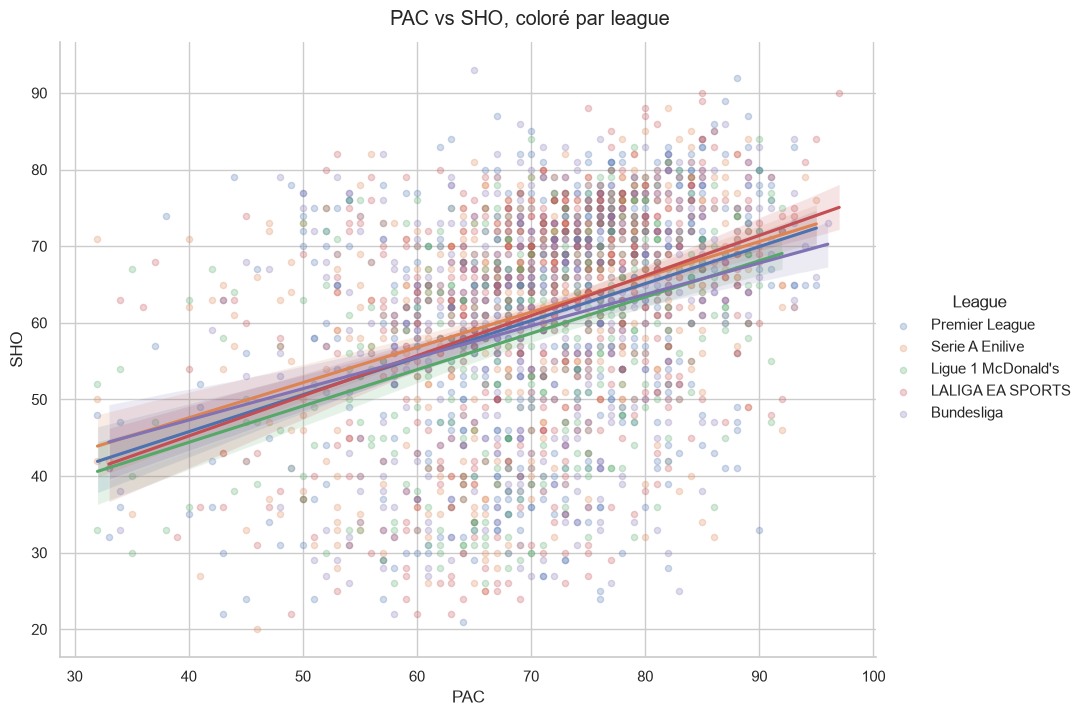

In [23]:
donnees_lm = df[df['League'].isin(top_5_ligues)][['PAC', 'SHO', 'League']].dropna()
echantillon_lm = donnees_lm.sample(n=min(3000, len(donnees_lm)), random_state=42)

graphique_lm = sns.lmplot(
    data=echantillon_lm, x='PAC', y='SHO', hue='League',
    height=7, aspect=1.3, scatter_kws={'alpha': 0.25, 's': 20}
)
graphique_lm.fig.suptitle('PAC vs SHO, coloré par league', y=1.02)
plt.show()

La relation entre PAC et SHO est positive mais modérée les attaquants ont souvent une bonne note de tir et plus de vitesse que les défenseurs qui ont généralement une note de tir plus faible et moins de vitesse.

Faire une heatmap de corrélation de toutes les stats numériques.

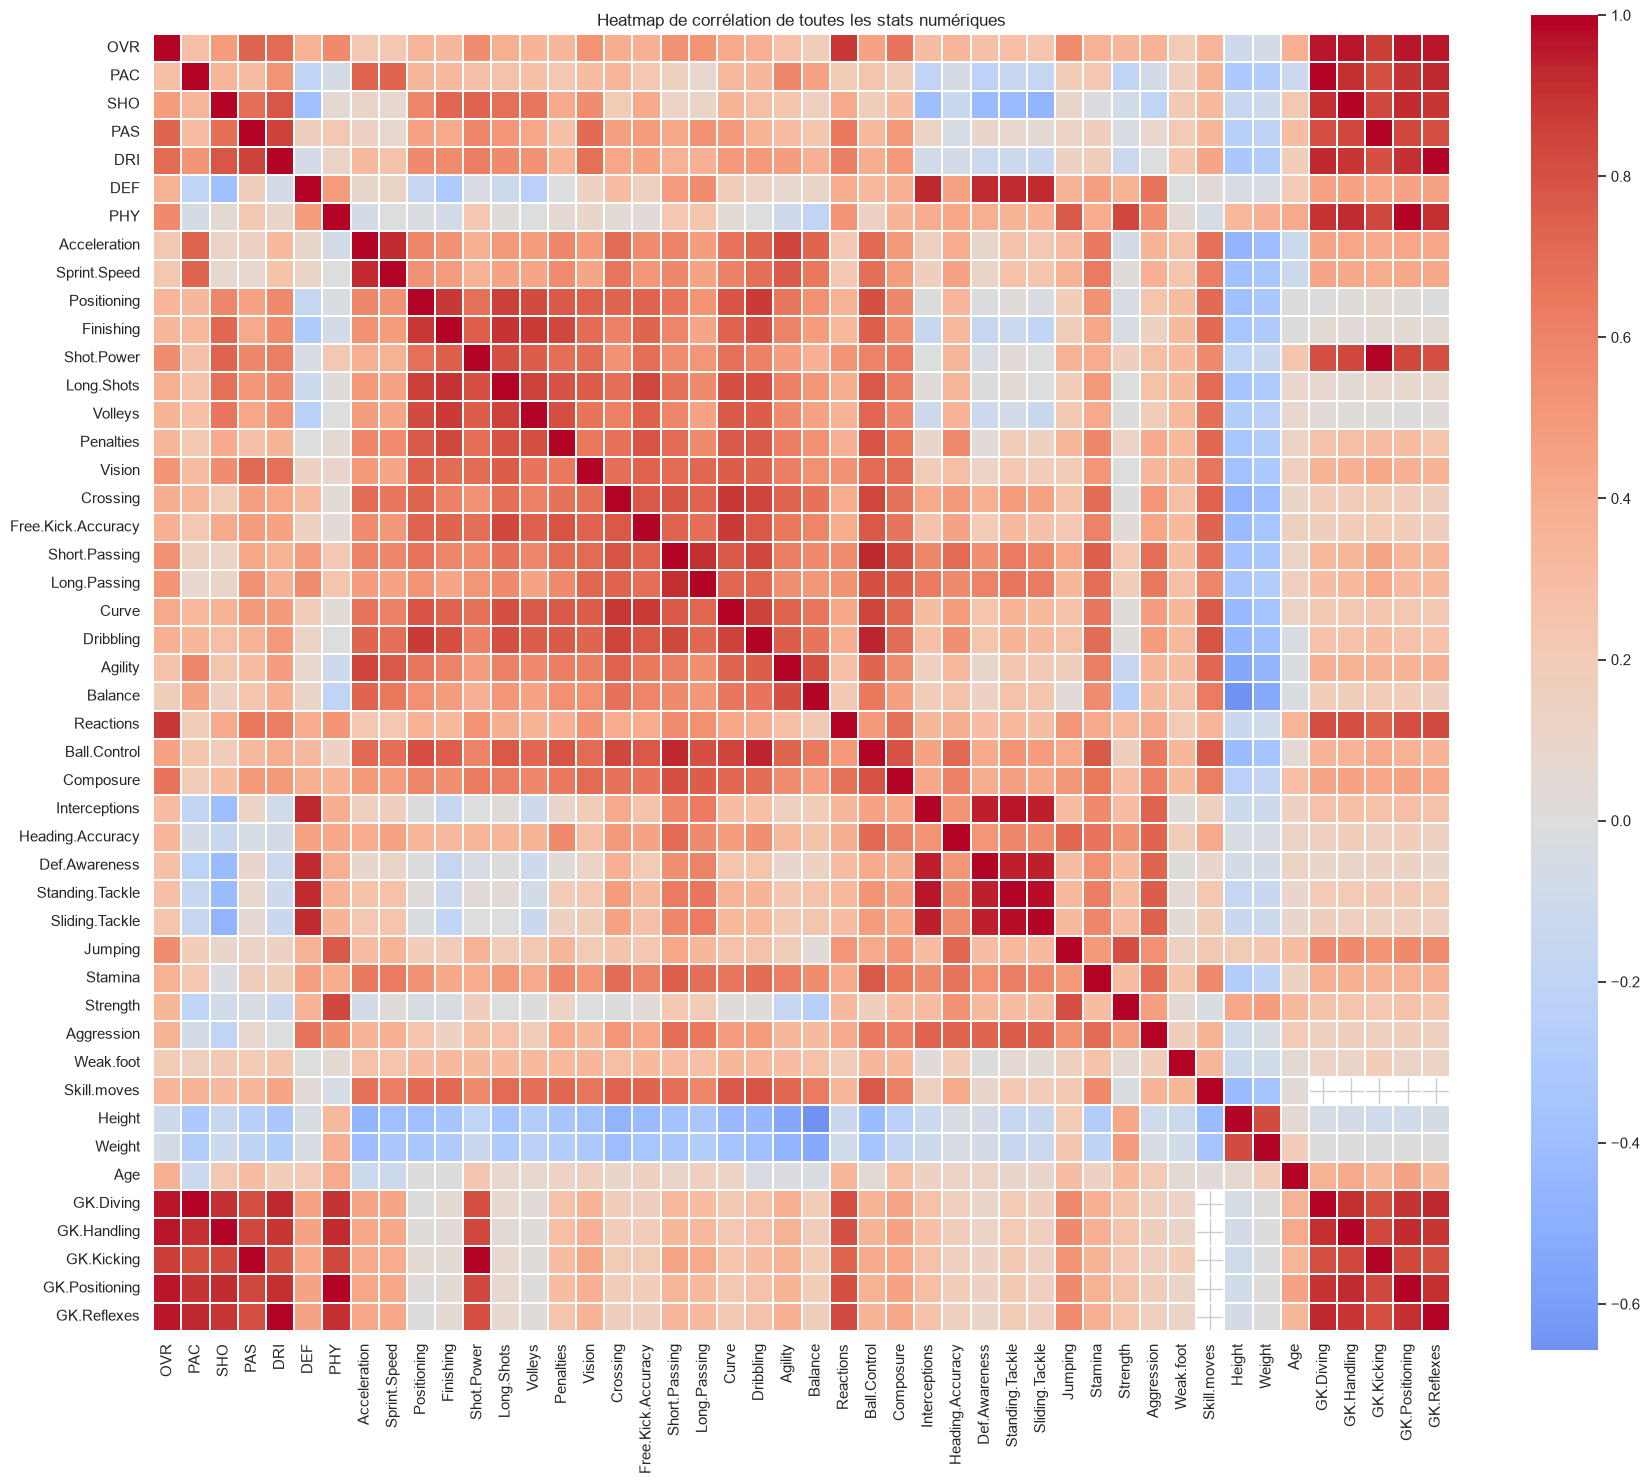

In [24]:
correlations = df.select_dtypes(include='number').corr()

plt.figure(figsize=(18, 15))
sns.heatmap(correlations, cmap='coolwarm', center=0, square=True, linewidths=0.2)
plt.title('Heatmap de corrélation de toutes les stats numériques')
plt.tight_layout()
plt.show()

Utiliser un FacetGrid pour afficher la distribution de OVR séparée par ligue.

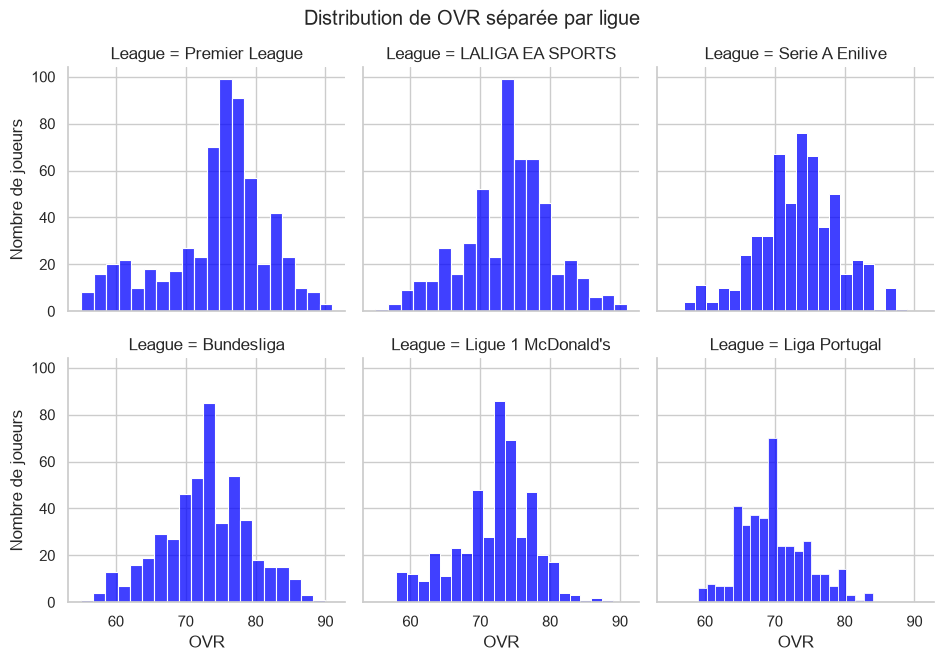

In [25]:
top_6_ligues = meilleures_ligues
donnees_facet = df[df['League'].isin(top_6_ligues)]

grid = sns.FacetGrid(
    donnees_facet,
    col='League',
    col_order=top_6_ligues,
    col_wrap=3,
    height=3.2,
    sharex=True,
    sharey=True
)
grid.map_dataframe(sns.histplot, x='OVR', bins=20, color='blue')
grid.set_axis_labels('OVR', 'Nombre de joueurs')
grid.fig.suptitle('Distribution de OVR séparée par ligue', y=1.03)
plt.show()

On voit bien que les grandes ligues ont de très bon joueurs à 90 OVR.

## 5. Visualisations orientées performance sportive

Quelle ligue a les joueurs les plus explosifs ? → moyenne de Acceleration + Sprint Speed par championnat.

Ligue avec les joueurs les plus explosifs : Premier League


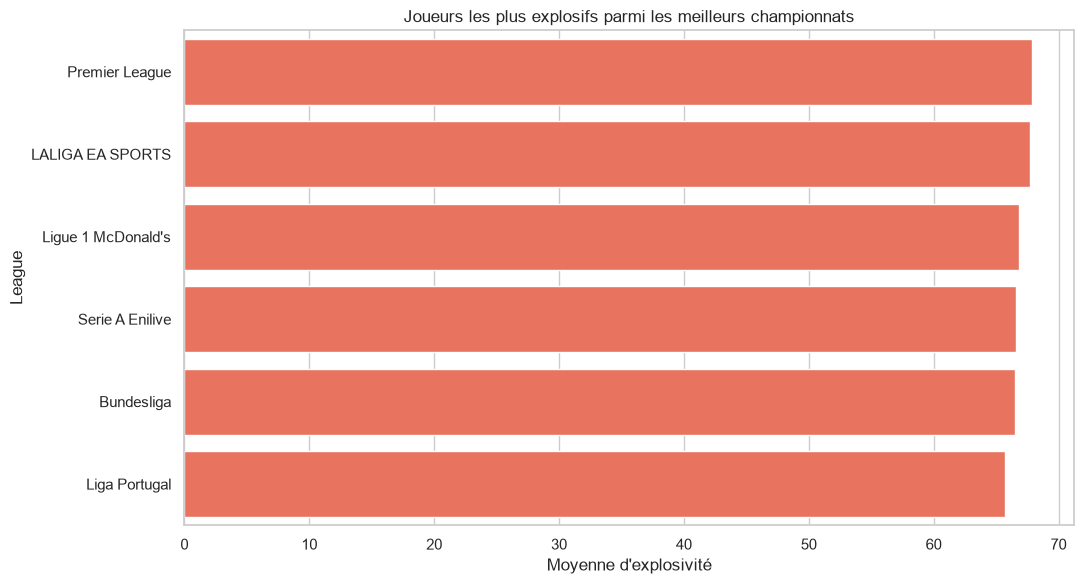

In [26]:
df['Explosivite'] = (df['Acceleration'] + df['Sprint.Speed']) / 2
moyenne_explosivite = (
    df[df['League'].isin(meilleures_ligues)]
    .groupby('League', as_index=False)['Explosivite'].mean()
    .sort_values('Explosivite', ascending=False)
)
print('Ligue avec les joueurs les plus explosifs :', moyenne_explosivite.iloc[0]['League'])

plt.figure(figsize=(11, 6))
sns.barplot(data=moyenne_explosivite, x='Explosivite', y='League', color='tomato')
plt.title('Joueurs les plus explosifs parmi les meilleurs championnats')
plt.xlabel("Moyenne d'explosivité")
plt.ylabel('League')
plt.tight_layout()
plt.show()

Représente l’équilibre “Attaque vs Défense” : → scatterplot (SHO + DRI) vs DEF.

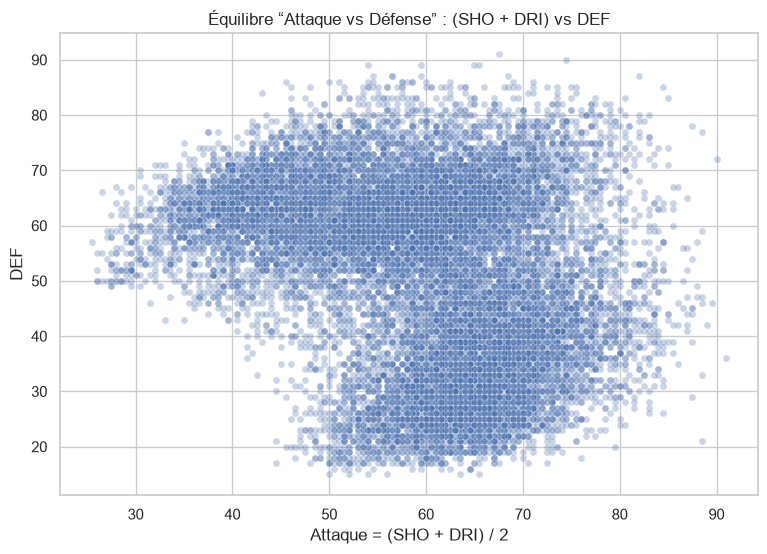

In [27]:
df['Attaque'] = (df['SHO'] + df['DRI']) / 2

plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='Attaque', y='DEF', alpha=0.3, s=25)
plt.title('Équilibre “Attaque vs Défense” : (SHO + DRI) vs DEF')
plt.xlabel('Attaque = (SHO + DRI) / 2')
plt.ylabel('DEF')
plt.show()

Les profils très offensifs ont souvent une note DEF plus faible.

Visualiser le profil moyen d’un joueur par championnat : → radar chart (matplotlib, en bonus).

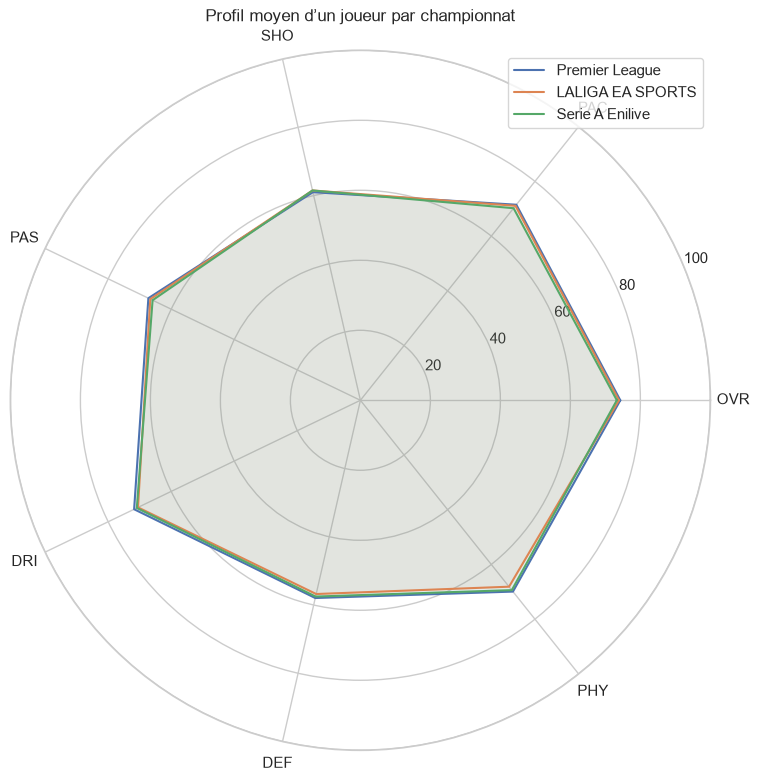

In [39]:
from math import pi

stats_radar = ['OVR', 'PAC', 'SHO', 'PAS', 'DRI', 'DEF', 'PHY']
profils_moyens = (
    df[df['League'].isin(trois_meilleures_ligues)]
    .groupby('League')[stats_radar]
    .mean()
    .reindex(trois_meilleures_ligues)
)
angles = [indice / len(stats_radar) * 2 * pi for indice in range(len(stats_radar))]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'polar': True})
for ligue, profil in profils_moyens.iterrows():
    valeurs = profil.tolist() + [profil.iloc[0]]
    ax.plot(angles, valeurs, label=ligue)
    ax.fill(angles, valeurs, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(stats_radar)
ax.set_ylim(0, 100)
ax.set_title('Profil moyen d’un joueur par championnat')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

Les trois meilleurs championnats ont des profils proches.

## 6. Exercices avancés

Crée un graphique montrant les 10 clubs avec les meilleures moyennes de OVR.

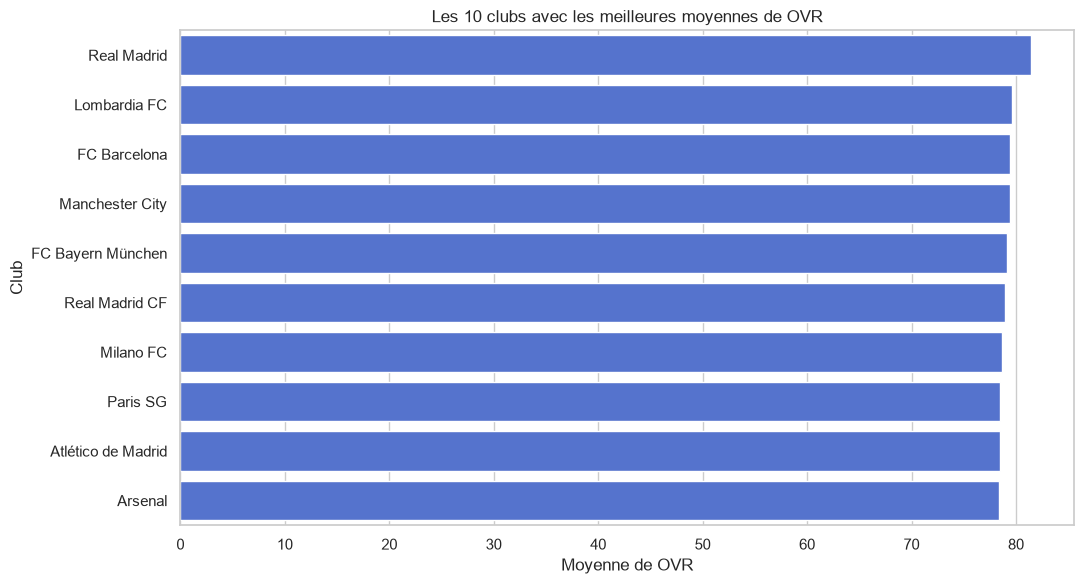

In [29]:
moyenne_ovr_clubs = (
    df.groupby('Team', as_index=False)['OVR']
    .mean()
    .sort_values('OVR', ascending=False)
    .head(10)
)

plt.figure(figsize=(11, 6))
sns.barplot(data=moyenne_ovr_clubs, x='OVR', y='Team', color='royalblue')
plt.title('Les 10 clubs avec les meilleures moyennes de OVR')
plt.xlabel('Moyenne de OVR')
plt.ylabel('Club')
plt.tight_layout()
plt.show()

Montre la distribution des gardians de but (variables GK.xxx) vs les joueurs de champ.

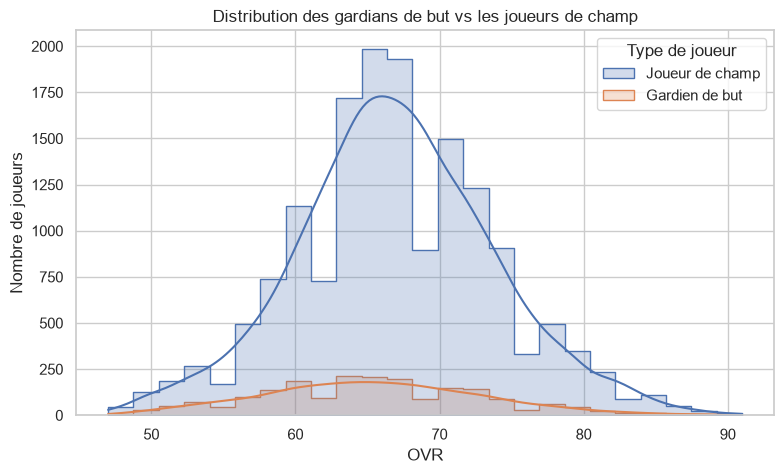

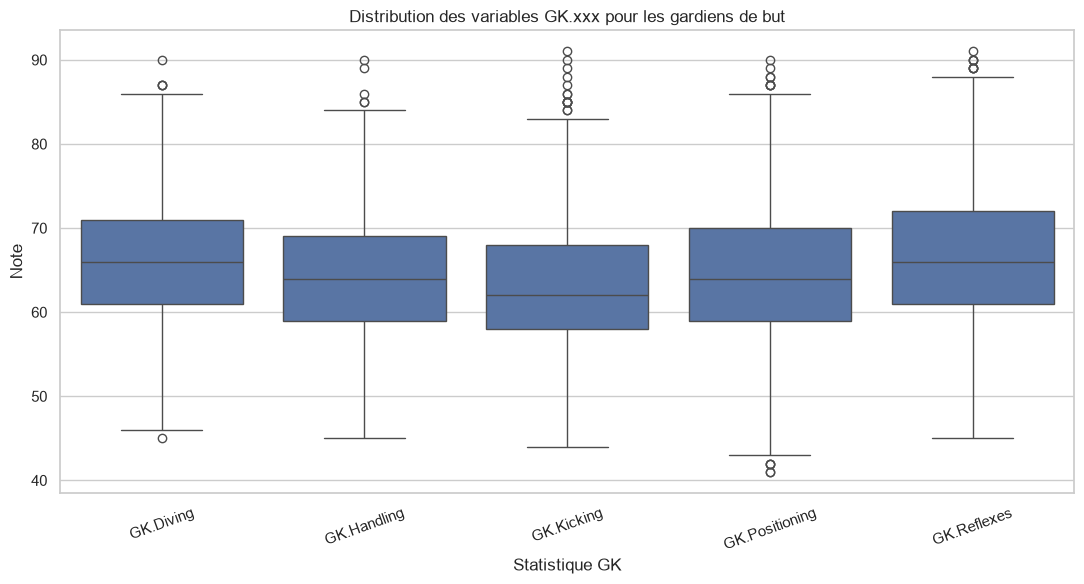

In [30]:
df['Type de joueur'] = df['Position'].eq('GK').map({True: 'Gardien de but', False: 'Joueur de champ'})

plt.figure(figsize=(9, 5))
sns.histplot(data=df, x='OVR', hue='Type de joueur', bins=25, kde=True, element='step', common_norm=False)
plt.title('Distribution des gardians de but vs les joueurs de champ')
plt.xlabel('OVR')
plt.ylabel('Nombre de joueurs')
plt.show()

statistiques_gardiens = ['GK.Diving', 'GK.Handling', 'GK.Kicking', 'GK.Positioning', 'GK.Reflexes']
donnees_gardiens = df.loc[df['Position'].eq('GK'), statistiques_gardiens].melt(
    var_name='Statistique GK', value_name='Note'
)

plt.figure(figsize=(11, 6))
sns.boxplot(data=donnees_gardiens, x='Statistique GK', y='Note')
plt.title('Distribution des variables GK.xxx pour les gardiens de but')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Les distributions d’OVR sont proches.

Compare la variance des statistiques d'un championnat à un autre (boxplot global).

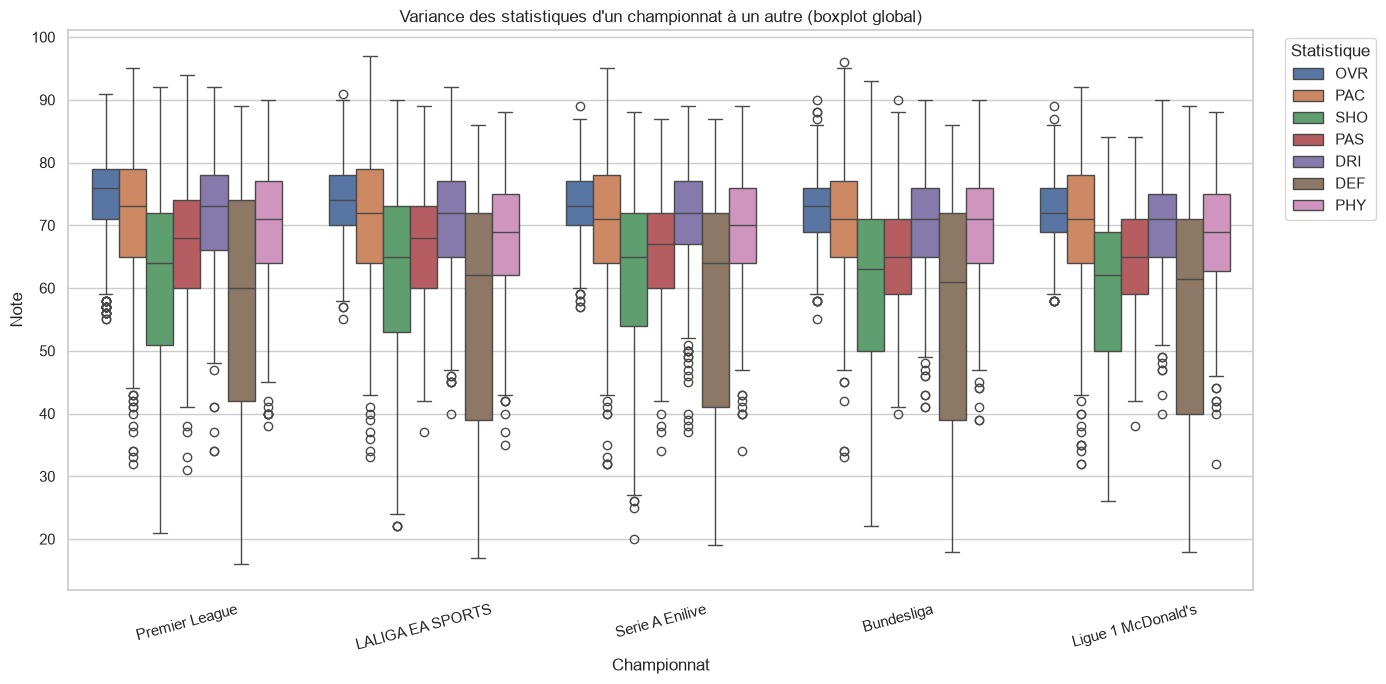

In [31]:
statistiques_globales = ['OVR', 'PAC', 'SHO', 'PAS', 'DRI', 'DEF', 'PHY']
top_5_ligues_variance = meilleures_ligues[:5]
donnees_variance = df[df['League'].isin(top_5_ligues_variance)].melt(
    id_vars='League',
    value_vars=statistiques_globales,
    var_name='Statistique',
    value_name='Note'
)

plt.figure(figsize=(14, 7))
sns.boxplot(
    data=donnees_variance,
    x='League',
    y='Note',
    hue='Statistique',
    order=top_5_ligues_variance
)
plt.title("Variance des statistiques d'un championnat à un autre (boxplot global)")
plt.xlabel('Championnat')
plt.ylabel('Note')
plt.xticks(rotation=15)
plt.legend(title='Statistique', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

La dispersion dépend plus de la statistique observée que du championnat.

Visualiser comment les stats “physiques” (PHY, DEF) varient par nation (catplot).

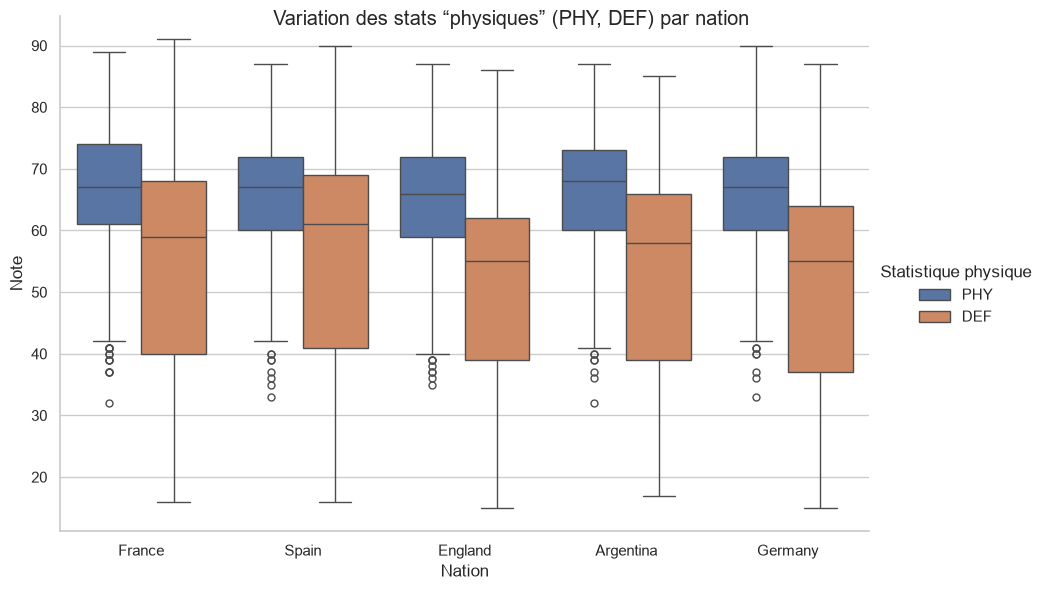

In [40]:
top_5_nations_physiques = df['Nation'].value_counts().head(5).index
donnees_physiques = df[df['Nation'].isin(top_5_nations_physiques)].melt(
    id_vars='Nation',
    value_vars=['PHY', 'DEF'],
    var_name='Statistique physique',
    value_name='Note'
)

graphique_physique = sns.catplot(
    data=donnees_physiques,
    x='Nation',
    y='Note',
    hue='Statistique physique',
    kind='box',
    height=6,
    aspect=1.5
)
graphique_physique.fig.suptitle('Variation des stats “physiques” (PHY, DEF) par nation')
graphique_physique.set_axis_labels('Nation', 'Note')
plt.show()

La France se distingue légèrement en PHY, tandis que l’Espagne obtient la moyenne DEF la plus élevée.